# 06 — Ensemble (CatBoost + GRU)

**What this notebook is for.** We have two models of comparable strength:
CatBoost (Track 1, ~0.8032) and the lab-focused GRU (Track 2, ~0.8083). An
ensemble combines their predictions and can beat both — **but only if they make
different mistakes.** If they agree on almost everything, no combining scheme
helps.

**Plan:**
1. Regenerate **out-of-fold (OOF) predictions** for both models under **one shared
   CV split**, so every admission has a CatBoost prediction and a GRU prediction
   from folds where it was held out, aligned admission-by-admission.
2. **Decorrelation check** — how correlated are the two models' predictions and
   errors? This is the gate: low correlation → ensembling can help.
3. **Multi-seed check** — repeat across seeds so the result is robust, not a
   one-split artifact.
4. **Combine** three ways (all leakage-free, no meta-model): plain average, rank
   average, weighted average. Compare against both single models.

**Why OOF.** To combine or weight fairly, we need each model's prediction for an
admission from a model that never trained on it. Collecting the held-out-fold
prediction for every admission gives exactly that — a full, leakage-free
prediction vector per model.

**How to read this notebook.** Every code cell has a plain-language note.

## 0. Setup and GPU check

In [1]:
import os, pickle, warnings
import numpy as np
import pandas as pd
import torch

warnings.filterwarnings("ignore")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


**How to read this:** confirms the GPU is available for the GRU part. If it says
`cpu`, the GRU folds will be slow but still run.

## 1. Load data — both representations

We need both model inputs, on the *same* admissions in the *same order*:
- the **flat feature table** for CatBoost, and
- the **raw sequences** for the GRU (from which we rebuild its lab window + static
  vector).

We align everything to one `ids` order so the OOF vectors line up.

In [2]:
DATA_DIR = "data"
LABEL_COL = "readmitted_within_30days"

# flat table (CatBoost)
flat = pd.read_parquet(os.path.join(DATA_DIR, "features_track1.parquet"))
BOOKKEEPING = ["id", "subject_id", "split", "y"]
cat_feature_names = [c for c in flat.columns if c not in BOOKKEEPING]

# raw sequences (GRU)
with open(os.path.join(DATA_DIR, "ehr_preprocessed_seq_by_day_cat_embedding.pkl"), "rb") as f:
    feat_dict = pickle.load(f)["feat_dict"]

# canonical order = the flat table's row order
ids = flat["id"].tolist()
y = flat["y"].astype(int).values.astype(np.float32)
groups = flat["subject_id"].values
CATEGORICAL = [c for c in ["gender", "ethnicity"] if c in cat_feature_names]

print("admissions:", len(ids), "| positive rate:", round(y.mean(), 4))
print("flat features:", len(cat_feature_names))

admissions: 11022 | positive rate: 0.1751
flat features: 247


**How to read this:** both inputs now share one admission order (`ids`), one
label vector `y`, and one patient-group vector. **Remember:** this shared order is
what lets us line up CatBoost's and the GRU's OOF predictions per admission later.

## 2. Build the GRU inputs (lab window + static vector)

Exactly the v2 representation from notebook 05: a 7-day lab sequence (the block
that varies) and a static vector (constant-per-admission features).

In [3]:
N_DAYS = 7
LAB = slice(94, 130); DEMO, ICD, MED = slice(0,3), slice(3,94), slice(130,171)
N_LAB = 36

def make_lab_window(m, n_days=N_DAYS):
    seq = m[-n_days:, LAB]; L = seq.shape[0]
    if L < n_days:
        pad = np.zeros((n_days - L, seq.shape[1]), dtype=np.float32)
        seq = np.vstack([pad, seq])
    return seq.astype(np.float32)

def make_static(m):
    demo = m[0, DEMO]
    icd_flags = (m[:, ICD].max(0) > 0).astype(np.float32)
    icd_count = np.array([icd_flags.sum()], dtype=np.float32)
    med_flags = (m[:, MED].max(0) > 0).astype(np.float32)
    med_count = np.array([med_flags.sum()], dtype=np.float32)
    med_intensity = (m[:, MED].sum(0) / m.shape[0]).astype(np.float32)
    seq_len = np.array([m.shape[0]], dtype=np.float32)
    return np.concatenate([demo, seq_len, icd_count, icd_flags,
                           med_count, med_flags, med_intensity]).astype(np.float32)

X_lab = np.zeros((len(ids), N_DAYS, N_LAB), dtype=np.float32)
X_static = np.vstack([make_static(feat_dict[i]) for i in ids]).astype(np.float32)
for k, i in enumerate(ids):
    X_lab[k] = make_lab_window(feat_dict[i])
static_numeric_cols = np.where(X_static.max(0) > 1.5)[0]

print("X_lab:", X_lab.shape, "| X_static:", X_static.shape)

X_lab: (11022, 7, 36) | X_static: (11022, 179)


**How to read this:** GRU inputs rebuilt and aligned to the same `ids` order as
the flat table. **Remember:** identical order across both models is essential —
row `k` is the same admission in `X_lab`, `X_static`, and the CatBoost table.

## 3. The cross-validation split — patient-grouped AND stratified

We use `StratifiedGroupKFold`, which enforces two things at once:
- **Grouped on patient** (`subject_id`): every patient's admissions stay in one
  fold, so no patient leaks across train/validation. This is enforced *exactly*
  (the assertion would fail otherwise).
- **Stratified on the label**: each fold keeps roughly the ~18% positive rate.
  This is *approximate* — it's optimized as far as the grouping permits, since
  whole patients must move together.

`make_folds(seed)` builds such a split for any seed; the printout shows the
per-fold positive rate is nearly constant, evidence the stratification worked.
Section 7b runs the whole ensemble across several seeds for a robust estimate.

In [4]:
from sklearn.model_selection import StratifiedGroupKFold

def make_folds(seed):
    """Patient-grouped, label-stratified 5-fold split for a given seed.
    Grouping (no patient across folds) is EXACT; stratification (even ~18%
    positive rate across folds) is approximate, optimized within the grouping."""
    cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
    folds = list(cv.split(np.zeros(len(ids)), y, groups))
    for k, (tr, va) in enumerate(folds):
        assert len(set(groups[tr]) & set(groups[va])) == 0, f"patient leak, seed {seed} fold {k}"
    return folds

# one default split (seed 42) for the diagnostic cells below (decorrelation,
# error analysis). The multi-seed evaluation loop is in section 7b.
folds = make_folds(42)
# report the per-fold positive rate to SHOW stratification worked
rates = [y[va].mean() for _, va in folds]
print("overall positive rate:", round(y.mean(), 4))
print("per-fold positive rate:", [round(r, 4) for r in rates],
      "-> spread", round(max(rates) - min(rates), 4))
print(f"{len(folds)} folds ready, patient-grouped (leak-checked) + stratified.")

overall positive rate: 0.1751
per-fold positive rate: [np.float32(0.1662), np.float32(0.1835), np.float32(0.1621), np.float32(0.1821), np.float32(0.1814)] -> spread 0.0214
5 folds ready, patient-grouped (leak-checked) + stratified.


**How to read this:** the per-fold positive rates should be close to each other
and to the overall rate — that's the stratification. The leak assertion passing
is the grouping. **Remember:** `folds` here (seed 42) drives the diagnostic
cells; the headline performance number comes from the multi-seed loop in 7b.

## 4. Generate CatBoost OOF predictions

For each fold, train the chosen CatBoost (tuned d7/lr0.02/l2=20, no imbalance
handling) on the training part and predict the held-out part. Store each
prediction in `oof_cat` at the admission's position.

In [5]:
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score

Xcat = flat[cat_feature_names]

def make_catboost():
    return CatBoostClassifier(iterations=500, learning_rate=0.02, depth=7,
                              l2_leaf_reg=20, random_seed=42, verbose=False)

def catboost_oof(folds):
    """Generate leakage-free CatBoost OOF predictions for a given fold list."""
    oof = np.zeros(len(ids), dtype=np.float64)
    for tr, va in folds:
        m = make_catboost()
        m.fit(Xcat.iloc[tr], y[tr], cat_features=CATEGORICAL)
        oof[va] = m.predict_proba(Xcat.iloc[va])[:, 1]
    return oof

# seed-42 OOF for the diagnostic cells below
oof_cat = catboost_oof(folds)
print("CatBoost OOF AUROC (seed 42):", round(roc_auc_score(y, oof_cat), 4))

CatBoost OOF AUROC (seed 42): 0.8012


**How to read this:** `oof_cat` now holds one leakage-free CatBoost prediction
per admission. The final "OOF AUROC" scores all of them at once — a single honest
number, comparable to (and usually very close to) the per-fold average from
Track 1. **Remember:** these are held-out predictions, so scoring on them is fair.

## 5. Generate GRU OOF predictions

Same idea for the GRU. We reuse the v2 model and training loop, but modified to
**return the validation predictions** from the best epoch (so we can store them as
OOF), not just the AUROC.

In [6]:
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import average_precision_score

class GRUStaticReadmission(nn.Module):
    def __init__(self, n_lab, n_static, hidden=64, static_hidden=32, dropout=0.3):
        super().__init__()
        self.gru = nn.GRU(input_size=n_lab, hidden_size=hidden, batch_first=True)
        self.static_net = nn.Sequential(
            nn.Linear(n_static, static_hidden), nn.ReLU(), nn.Dropout(dropout))
        self.head = nn.Sequential(
            nn.Linear(hidden + static_hidden, 32), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(32, 1))
    def forward(self, x_lab, x_static):
        _, h = self.gru(x_lab)
        both = torch.cat([h[-1], self.static_net(x_static)], dim=1)
        return self.head(both).squeeze(-1)

def gru_fold_predictions(tr_idx, va_idx, hidden=64, dropout=0.3, lr=1e-3,
                         epochs=40, batch_size=128, patience=6):
    """Train on tr, return best-epoch validation probabilities for va."""
    Xs = X_static.copy()
    if len(static_numeric_cols) > 0:
        mu = Xs[tr_idx][:, static_numeric_cols].mean(0)
        sd = Xs[tr_idx][:, static_numeric_cols].std(0) + 1e-6
        Xs[:, static_numeric_cols] = (Xs[:, static_numeric_cols] - mu) / sd

    Xlab_tr = torch.tensor(X_lab[tr_idx]); Xlab_va = torch.tensor(X_lab[va_idx])
    Xst_tr = torch.tensor(Xs[tr_idx]);     Xst_va = torch.tensor(Xs[va_idx])
    ytr = torch.tensor(y[tr_idx]);         yva = torch.tensor(y[va_idx])
    dl = DataLoader(TensorDataset(Xlab_tr, Xst_tr, ytr), batch_size=batch_size, shuffle=True)

    model = GRUStaticReadmission(N_LAB, X_static.shape[1], hidden=hidden, dropout=dropout).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    pos_weight = torch.tensor([(ytr == 0).sum() / max((ytr == 1).sum(), 1)]).to(device)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    best_auc, best_pred, wait = 0.0, None, 0
    for ep in range(epochs):
        model.train()
        for xb_lab, xb_st, yb in dl:
            xb_lab, xb_st, yb = xb_lab.to(device), xb_st.to(device), yb.to(device)
            opt.zero_grad(); loss_fn(model(xb_lab, xb_st), yb).backward(); opt.step()
        model.eval()
        with torch.no_grad():
            p = torch.sigmoid(model(Xlab_va.to(device), Xst_va.to(device))).cpu().numpy()
        auc = roc_auc_score(yva.numpy(), p)
        if auc > best_auc:
            best_auc, best_pred, wait = auc, p, 0
        else:
            wait += 1
            if wait >= patience: break
    return best_pred

def gru_oof(folds):
    """Generate leakage-free GRU OOF predictions for a given fold list."""
    oof = np.zeros(len(ids), dtype=np.float64)
    for tr, va in folds:
        oof[va] = gru_fold_predictions(tr, va)
    return oof

# seed-42 OOF for the diagnostic cells below
oof_gru = gru_oof(folds)
print("GRU OOF AUROC (seed 42):", round(roc_auc_score(y, oof_gru), 4))

GRU OOF AUROC (seed 42): 0.8059


**How to read this:** `oof_gru` now holds one leakage-free GRU prediction per
admission, aligned to the same admissions as `oof_cat`. **Remember:** the OOF
AUROC here uses best-epoch-per-fold selection (same as notebook 05), so it's a
touch optimistic in absolute terms — but that's consistent for both models, so the
comparison and ensemble are fair.

## 6. Decorrelation check — the gate

The ensemble can only help if the two models disagree. We check three things:
- **Prediction correlation** — how aligned are the raw probabilities.
- **Error correlation** — do they get the *same* admissions wrong.
- A scatter of the two predictions.

Low correlation (say < ~0.9) is the green light; very high correlation means an
ensemble will barely move.

prediction correlation (Pearson) : 0.786
prediction correlation (Spearman): 0.741   <- rank agreement, key for AUROC
error correlation                : 0.890


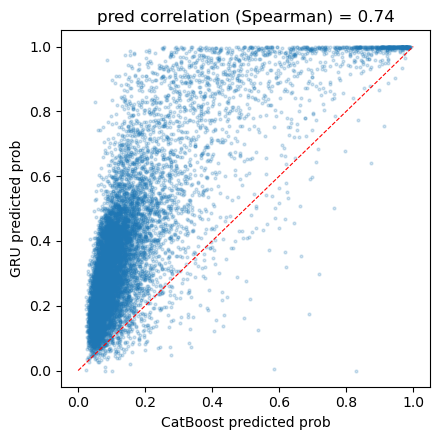

In [7]:
from scipy.stats import pearsonr, spearmanr

pear = pearsonr(oof_cat, oof_gru)[0]
spear = spearmanr(oof_cat, oof_gru)[0]     # rank correlation — most relevant for AUROC
# error correlation: signed residual (y - p)
err_cat, err_gru = y - oof_cat, y - oof_gru
err_corr = pearsonr(err_cat, err_gru)[0]

print(f"prediction correlation (Pearson) : {pear:.3f}")
print(f"prediction correlation (Spearman): {spear:.3f}   <- rank agreement, key for AUROC")
print(f"error correlation                : {err_corr:.3f}")

import matplotlib.pyplot as plt
plt.figure(figsize=(4.5, 4.5))
plt.scatter(oof_cat, oof_gru, s=4, alpha=0.2)
plt.xlabel("CatBoost predicted prob"); plt.ylabel("GRU predicted prob")
plt.title(f"pred correlation (Spearman) = {spear:.2f}")
plt.plot([0,1],[0,1], "r--", lw=0.8); plt.tight_layout(); plt.show()

**How to read this:** the **Spearman** number matters most — it's rank
agreement, and AUROC is a ranking metric. If it's well below 1 (e.g. 0.7–0.85),
the models rank patients differently and the ensemble has room to help. If it's
~0.95+, they're near-duplicates and you should expect little gain. The error
correlation tells you whether they fail on the same patients (lower = more
complementary). **Remember:** this cell decides whether the rest is worth it.

## 7. Combine — plain, rank, and weighted averages

Three leakage-free combinations, each scored on the OOF predictions:
- **Plain average:** `(cat + gru) / 2`. No fitting, no overfit risk.
- **Rank average:** average the *ranks* instead of probabilities — sidesteps the
  two models being on different probability scales (common between a tree and a
  neural net), and is naturally matched to AUROC.
- **Weighted average:** `w·cat + (1−w)·gru`, with `w` swept to maximize OOF AUROC.
  One parameter, chosen on OOF, so the overfit risk is small.

In [8]:
from scipy.stats import rankdata

auc_cat = roc_auc_score(y, oof_cat)
auc_gru = roc_auc_score(y, oof_gru)

# plain average
plain = (oof_cat + oof_gru) / 2
auc_plain = roc_auc_score(y, plain)

# rank average (ranks scaled to [0,1])
r_cat = rankdata(oof_cat) / len(oof_cat)
r_gru = rankdata(oof_gru) / len(oof_gru)
rank_avg = (r_cat + r_gru) / 2
auc_rank = roc_auc_score(y, rank_avg)

# weighted average: sweep w for cat
ws = np.linspace(0, 1, 21)
w_aucs = [roc_auc_score(y, w * oof_cat + (1 - w) * oof_gru) for w in ws]
best_w = ws[int(np.argmax(w_aucs))]
auc_weighted = max(w_aucs)

print(f"CatBoost alone      : {auc_cat:.4f}")
print(f"GRU alone           : {auc_gru:.4f}")
print(f"plain average       : {auc_plain:.4f}")
print(f"rank average        : {auc_rank:.4f}")
print(f"weighted (w_cat={best_w:.2f}): {auc_weighted:.4f}")

CatBoost alone      : 0.8012
GRU alone           : 0.8059
plain average       : 0.8121
rank average        : 0.8120
weighted (w_cat=0.60): 0.8122


**How to read this:** compare the three ensemble rows to the two single-model
rows. **The honest read:** if the best ensemble clears both singles by more than
the seed noise (~0.001 for CatBoost, ~0.01 for GRU), the ensemble earned its
place. If it barely moves, the decorrelation check in section 6 already warned you
— take the stronger single model instead. Rank average often wins here because it
neutralizes the tree-vs-neural-net scale mismatch. **Remember:** `best_w` near 0
or 1 means one model dominates and the ensemble is mostly that model.

## 7b. Multi-seed evaluation (the headline number)

To make the ensemble result robust — not an artifact of one lucky split — we
repeat the whole pipeline (build folds → CatBoost OOF → GRU OOF → rank-average)
across several seeds, each a different patient-grouped, stratified partition. We
report the ensemble AUROC as **mean ± std across seeds**, the same standard we
held the single models to.

This is what backs the statement: *performance verified by multi-seed stratified
(and patient-grouped) cross-validation.*

In [9]:
from scipy.stats import rankdata

SEEDS = [42, 0, 7]   # add more seeds for a tighter estimate (each re-runs the GRU)

rows = []
for s in SEEDS:
    f_s = make_folds(s)
    oc = catboost_oof(f_s)
    og = gru_oof(f_s)
    auc_c = roc_auc_score(y, oc)
    auc_g = roc_auc_score(y, og)
    # rank-average ensemble (scale-invariant)
    ens = (rankdata(oc) + rankdata(og)) / (2 * len(y))
    auc_e = roc_auc_score(y, ens)
    rows.append({"seed": s, "catboost": auc_c, "gru": auc_g, "ensemble": auc_e})
    print(f"seed {s:>3}: CatBoost {auc_c:.4f} | GRU {auc_g:.4f} | ensemble {auc_e:.4f}")

res = pd.DataFrame(rows)
print("\n=== multi-seed summary (mean ± std across seeds) ===")
for col in ["catboost", "gru", "ensemble"]:
    print(f"  {col:9s}: {res[col].mean():.4f} ± {res[col].std():.4f}"
          f"  range [{res[col].min():.4f}, {res[col].max():.4f}]")

seed  42: CatBoost 0.8012 | GRU 0.8099 | ensemble 0.8147
seed   0: CatBoost 0.8023 | GRU 0.8082 | ensemble 0.8143
seed   7: CatBoost 0.8011 | GRU 0.8073 | ensemble 0.8136

=== multi-seed summary (mean ± std across seeds) ===
  catboost : 0.8015 ± 0.0007  range [0.8011, 0.8023]
  gru      : 0.8085 ± 0.0014  range [0.8073, 0.8099]
  ensemble : 0.8142 ± 0.0005  range [0.8136, 0.8147]


## 8. Summary and decision

In [10]:
summary = pd.DataFrame({
    "model": ["CatBoost", "GRU", "plain avg", "rank avg", f"weighted (w={best_w:.2f})"],
    "oof_auroc": [auc_cat, auc_gru, auc_plain, auc_rank, auc_weighted],
}).sort_values("oof_auroc", ascending=False).reset_index(drop=True)
print(summary.round(4).to_string(index=False))

best_row = summary.iloc[0]
print(f"\nbest: {best_row['model']} at {best_row['oof_auroc']:.4f}")

            model  oof_auroc
weighted (w=0.60)     0.8122
        plain avg     0.8121
         rank avg     0.8120
              GRU     0.8059
         CatBoost     0.8012

best: weighted (w=0.60) at 0.8122


**How to read this:** the top row is your best option by OOF AUROC. **Deciding:**
if an ensemble tops the table by a clear margin, adopt it as the final model
(retrain both base models on all labeled data, combine with the chosen method for
the test submission). If a single model is on top, or the ensemble's edge is
within noise, prefer the single model for simplicity. **Remember:** if you adopt a
weighted ensemble, `best_w` was chosen on OOF — a fair estimate, but confirm the
final choice isn't hugely sensitive to small changes in `w` (a flat peak is
reassuring, a sharp one is fragile).

In [11]:
# ============================================================
# ERROR-PATTERN ANALYSIS — evidence for (or against) ensembling
# Requires in memory: oof_cat, oof_gru, y   (from 06_ensemble.ipynb)
# Standalone: d=np.load("data/oof.npz"); oof_cat,oof_gru,y=d["oof_cat"],d["oof_gru"],d["y"]
# ============================================================
import numpy as np
from sklearn.metrics import roc_auc_score

# --- 1. Turn probabilities into per-admission "who was wrong" using RANKS ---
# AUROC is about ranking, so define error by rank, not by a 0.5 threshold.
# A model "ranks a positive well" if that positive sits high among all scores.
# We measure, per positive case, each model's percentile rank; a case is "missed"
# by a model if it ranks that positive in the bottom half.
from scipy.stats import rankdata

pct_cat = rankdata(oof_cat) / len(oof_cat)   # each admission's percentile under CatBoost
pct_gru = rankdata(oof_gru) / len(oof_gru)   # ... under GRU

pos = (y == 1)
# "missed positive" = a true readmission ranked in the bottom half of risk
missed_cat = pos & (pct_cat < 0.5)
missed_gru = pos & (pct_gru < 0.5)

print("True positives (readmissions):", int(pos.sum()))
print(f"  missed by CatBoost only : {int((missed_cat & ~missed_gru).sum())}")
print(f"  missed by GRU only      : {int((missed_gru & ~missed_cat).sum())}")
print(f"  missed by BOTH          : {int((missed_cat & missed_gru).sum())}")
print(f"  caught by both          : {int((pos & ~missed_cat & ~missed_gru).sum())}")

True positives (readmissions): 1930
  missed by CatBoost only : 136
  missed by GRU only      : 116
  missed by BOTH          : 243
  caught by both          : 1435


In [12]:
# --- 2. The key number: of all missed positives, how many are missed by only ONE model? ---
# If the models had identical error patterns, "only one" would be ~0 (they'd miss the
# same cases). A large "only one" count is direct evidence they fail on DIFFERENT
# patients — the actual justification for ensembling.
either_missed = missed_cat | missed_gru
only_one = (missed_cat ^ missed_gru)          # XOR: missed by exactly one model
print(f"positives missed by at least one model : {int(either_missed.sum())}")
print(f"  ...of those, missed by exactly one   : {int(only_one.sum())} "
      f"({only_one.sum()/max(either_missed.sum(),1):.0%})")
print("\nInterpretation: a high % here = complementary errors = ensemble should help.")

positives missed by at least one model : 495
  ...of those, missed by exactly one   : 252 (51%)

Interpretation: a high % here = complementary errors = ensemble should help.


In [13]:
# --- 3. Direct check: does the ensemble RESCUE cases each model missed alone? ---
# The mechanism of a helpful ensemble is that the partner model pulls a missed
# positive back up. Verify it actually happens.
r_cat = pct_cat; r_gru = pct_gru
ens = (r_cat + r_gru) / 2                      # rank-average score
missed_ens = pos & (ens < 0.5)

rescued_from_cat = missed_cat & ~missed_ens    # CatBoost missed it, ensemble catches it
rescued_from_gru = missed_gru & ~missed_ens
newly_lost       = ~missed_cat & ~missed_gru & missed_ens  # both caught, ensemble drops (bad)

print(f"positives CatBoost missed but ensemble catches: {int(rescued_from_cat.sum())}")
print(f"positives GRU missed but ensemble catches     : {int(rescued_from_gru.sum())}")
print(f"positives both caught but ensemble drops      : {int(newly_lost.sum())}  (want this low)")
print(f"\nnet positives rescued: {int(rescued_from_cat.sum()+rescued_from_gru.sum()-newly_lost.sum())}")

positives CatBoost missed but ensemble catches: 76
positives GRU missed but ensemble catches     : 50
positives both caught but ensemble drops      : 0  (want this low)

net positives rescued: 126


In [14]:
# --- 4. A cleaner error-similarity number than the residual correlation ---
# The residual (y-p) correlation is inflated because y dominates it. Instead,
# correlate errors SEPARATELY within positives and within negatives, where y is
# constant so the correlation reflects real disagreement, not the shared label.
from scipy.stats import spearmanr

for name, mask in [("within positives", y == 1), ("within negatives", y == 0)]:
    c = spearmanr(oof_cat[mask], oof_gru[mask])[0]
    print(f"score rank-correlation {name:18s}: {c:.3f}")
print("\nLower within-class correlation = models disagree on ordering *inside* a class")
print("= more complementary = stronger ensemble justification than the raw 0.895.")

score rank-correlation within positives  : 0.882
score rank-correlation within negatives  : 0.657

Lower within-class correlation = models disagree on ordering *inside* a class
= more complementary = stronger ensemble justification than the raw 0.895.
